In [1]:
from scipy.spatial.distance import mahalanobis
from scipy.interpolate import CubicSpline
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy import stats
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
import seaborn as sns
from tqdm import tqdm
import warnings
import pickle
from sklearn.feature_selection import mutual_info_regression
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from collections import deque
from itertools import islice
import re

In [2]:
warnings.filterwarnings("ignore")

In [3]:
monthly_avs = xr.open_dataset(r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\ERA5_32yr_monthly_avg.nc")
df = pd.read_csv(r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\df_preprocessed.csv")

In [4]:
monthly_avs

<xarray.Dataset> Size: 2GB
Dimensions:         (month: 12, pressure_level: 28, latitude: 360,
                     longitude: 720)
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 224B 1e+03 975.0 ... 100.0 70.0
  * latitude        (latitude) float64 3kB 89.88 89.38 88.88 ... -89.12 -89.62
  * longitude       (longitude) float64 6kB 0.125 0.625 1.125 ... 359.1 359.6
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    z               (month, pressure_level, latitude, longitude) float32 348MB ...
    t               (month, pressure_level, latitude, longitude) float32 348MB ...
    q               (month, pressure_level, latitude, longitude) float32 348MB ...
    r               (month, pressure_level, latitude, longitude) float32 348MB ...
    o3              (month, pressure_level, latitude, longitude) float32 348MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [5]:
monthly_avs['q'] = monthly_avs['q'] * 1000  # This directly modifies the dataset to use g/kg

In [6]:
# Split data by koppen_cluster_spatial
# cluster_groups = df.groupby('koppen_spatial_relabel_reclass')
cluster_groups = df.groupby('koppen_spatial_relabel_reclass')

In [7]:
# First loop: Collect all climate vectors for the group
for cluster_id, group in cluster_groups:
    climate_vectors = []  # Reset for each group

    # Collect climate vectors for all samples in the group
    for idx, row in tqdm(group.iterrows(), total=len(group), desc=f'Processing Cluster {cluster_id}', unit='sample'):
        sample_lat, sample_lon = row['Latitude_-24'], row['Longitude_-24']
        sample_alt = row['AltP_meters_-24']
        sample_month = row['Month']

        # Extract ERA5 vertical profile at sample location
        profile_data = monthly_avs.sel(
            month=sample_month,
            latitude=sample_lat,
            longitude=sample_lon,
            method='nearest'
        )

        # Get geopotential heights from pressure levels and convert to meters
        geo_heights = profile_data.z.values / 9.80665  # Convert geopotential to height
        pressure_levels = profile_data.pressure_level.values  # Pressure levels
        
        # Extract temperature, q, and r profiles
        temp_profile = profile_data.t.values
        q_profile = profile_data.q.values
        r_profile = profile_data.r.values

        # Create cubic splines for each variable with respect to geopotential height
        temp_spline = CubicSpline(geo_heights, temp_profile)
        q_spline = CubicSpline(geo_heights, q_profile)
        r_spline = CubicSpline(geo_heights, r_profile)

        # Evaluate the splines at the sample's altitude
        adj_temp = temp_spline(sample_alt)
        adj_q = q_spline(sample_alt)
        adj_r = r_spline(sample_alt)

        # Define climate vector and store it
        climate_vec = np.array([adj_temp, adj_q, adj_r])
        climate_vectors.append(climate_vec)

    # Convert the list of climate vectors to a numpy array (shape: [num_samples, 3])
    climate_vectors = np.array(climate_vectors)

    # Calculate the covariance matrix for the group (based on its own statistics)
    cov_matrix = np.cov(climate_vectors.T)  # Covariance of the group

    # Second loop: Calculate Mahalanobis distance for each sample in the group
    manual_index = 0
    for idx, row in tqdm(group.iterrows(), total=len(group), desc=f'Calculating Mahalanobis for Cluster {cluster_id}', unit='sample'):
        sample_temp, sample_q, sample_r = row[['Temperature_-24', 'Specific_Humidity_-24', 'Relative_Humidity_-24']]
        sample_vec = np.array([sample_temp, sample_q, sample_r])

        # Get the specific climate vector for the current sample
        climate_vec_sample = climate_vectors[manual_index]

        # Calculate Mahalanobis distance for the specific sample's vector
        try:
            inv_cov = np.linalg.inv(cov_matrix)  # Inverse of covariance matrix
            distance = mahalanobis(sample_vec, climate_vec_sample, inv_cov)  # Sample-specific distance
        except np.linalg.LinAlgError:
            distance = np.nan  # Handle singular matrix gracefully
        
        # Add the Mahalanobis distance as a new column to the dataframe
        df.loc[row.name, 'mahalanobis_distance_climate'] = distance
        
        # Calculate Mahalanobis distance using the mean climate vector of the group
        try:
            distance_mean = mahalanobis(sample_vec, climate_vectors.mean(axis=0), inv_cov)  # Group mean distance
        except np.linalg.LinAlgError:
            distance_mean = np.nan  # Handle singular matrix gracefully
        
        # Add the Mahalanobis distance based on the mean climate vector as a new column
        df.loc[row.name, 'mahalanobis_distance_group'] = distance_mean

        # Store the number of samples in the group
        df.loc[row.name, 'kgccl_group_n'] = len(group)

        manual_index += 1

Calculating Mahalanobis for Cluster 82: 100%|██████████| 373/373 [00:00<00:00, 1408.83sample/s]


In [8]:
len(df['mahalanobis_distance_climate'])

46177

In [9]:
threshold = 10
count = (df['mahalanobis_distance_climate'] > threshold).sum()
print(count)

236


In [10]:
threshold = 10
df.loc[df['mahalanobis_distance_climate'] > threshold, 'mahalanobis_distance_climate'] = np.nan

In [11]:
np.save(r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\mahalanobis_distances_koppen_1_30.npy", df['mahalanobis_distance_climate'].values)

In [12]:
threshold = 5
count = (df['mahalanobis_distance_climate'] > threshold).sum()
print(count)

2263


In [13]:
koppen_spatial = np.load(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\koppen_ccl_remapped.npy")
rolled_koppen_ll = np.load(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\rolled_koppen_ll.npy")
with open(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\koppen_cmap.pkl", 'rb') as file:
    koppen_cmap = pickle.load(file)

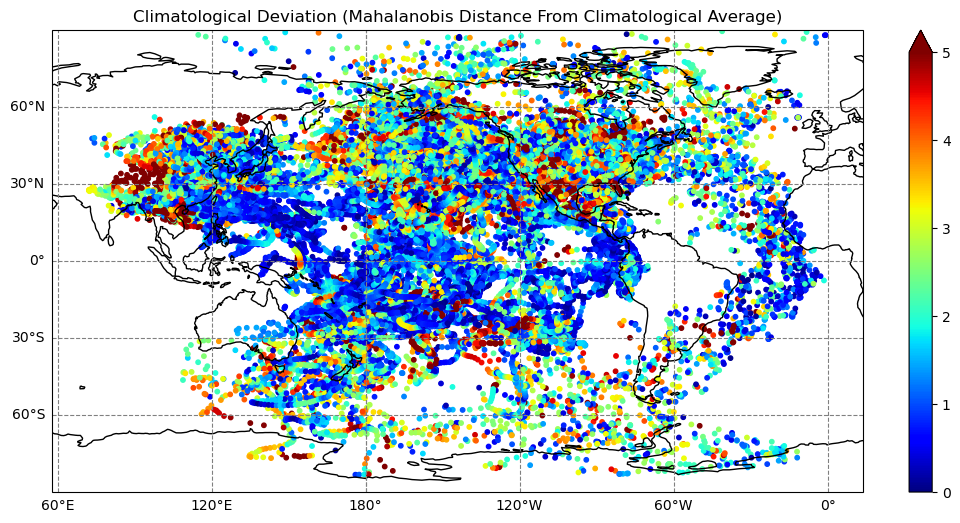

In [14]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

# # === Plot the Köppen-Geiger regions as background ===
# land_plot = ax.pcolormesh(
#     rolled_koppen_ll[..., 1],
#     rolled_koppen_ll[..., 0],
#     koppen_spatial,
#     cmap=koppen_cmap,
#     shading='auto',
#     alpha=0.2,  # Lower opacity for background
#     transform=ccrs.PlateCarree(),
# )

# Plot the data
sc = ax.scatter(
    df['Longitude_-24'].values, 
    df['Latitude_-24'].values, 
    c=df['mahalanobis_distance_climate'].values,
    cmap='jet',
    # cmap=land_cmap,
    # norm=land_norm, 
    s=10, 
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=5,
)

# Add coastlines
ax.coastlines()

# Add gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
gl.top_labels = gl.right_labels = False  # optional: turn off top/right labels for cleaner look

# Create colorbar with proper labels
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.025, extend='max')

# Title and show plot
plt.title("Climatological Deviation (Mahalanobis Distance From Climatological Average)")
plt.savefig(r"C:\Users\vwgei\Documents\PVOCAL\plots\standalone\mahalanobis_climate_distance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.clf()
plt.close()

In [15]:
# Group by 'koppen_spatial_relabel_reclass' and calculate stats for multiple columns
# cluster_stats = df.groupby('koppen_spatial_relabel_reclass').agg({
cluster_stats = df.groupby('koppen_spatial_relabel_reclass').agg({
    'mahalanobis_distance_climate': ['mean', 'std'],
    'mahalanobis_distance_group': ['mean', 'std'],
    'Latitude_-24' : ['mean', 'std'],
    'Longitude_-24' : ['mean', 'std'],
    'AltP_meters_-24': ['mean', 'std'],
    'Specific_Humidity_0' : ['mean', 'std'],
    'Potential_Temperature_0' : ['mean', 'std'],
    'mean_lcl' : ['mean', 'std'],
    'bearings_from_origin_-24' : ['mean', 'std'],
    'sum_moisture_flux' : ['mean', 'std'],
    'mean_mixing_depth' : ['mean', 'std'],
    'sum_solar_radiation' : ['mean', 'std'],
    'domain_indicator' : ['mean', 'std'],
    'time_difference_seconds_0' : ['mean', 'std'],
    'cos_julian_day' : ['mean', 'std'],
    'hour_cos_0' : ['mean', 'std'],
    'kgccl_group_n': 'mean',
}).reset_index()

In [16]:
cluster_stats

koppen_spatial_relabel_reclass mahalanobis_distance_climate            \
                                                          mean       std   
0                               1                     2.173582  1.803526   
1                               2                     1.390979  1.094259   
2                               3                     1.211171  0.976307   
3                               4                     1.376040  0.938861   
4                               5                     2.325765  1.694523   
..                            ...                          ...       ...   
77                             78                     2.318705  1.204402   
78                             79                     6.584232  1.536718   
79                             80                     2.261939  1.241987   
80                             81                     2.025904  1.063076   
81                             82                     2.458639  1.293600   

   mahalanobis_distance_group           Latitude_-24            Longitude_-24  \
                         mean       std         mean        std          mean   
0                    2.557423  1.526849    34.002661   1.959091    -68.817770   
1                    2.192207  1.122093    28.550506   2.611618    134.973792   
2                    1.701676  0.849878    -6.153427  12.167229    -40.512527   
3                    1.701210  0.875529    -0.996252   4.056747    -64.110077   
4                    2.451683  1.874068   -15.607103   1.984793   -144.605874   
..                        ...       ...          ...        ...           ...   
77                   2.605300  1.015873    64.538147   7.687611    -85.535289   
78                   6.487596  1.427791    32.273366   3.290312     92.140451   
79                   2.740771  1.252778   -57.781415   5.610943      9.788682   
80                   2.300852  0.989322    80.155094   4.423183    -89.307796   
81                   2.867758  1.953760   -73.245845   4.668089    -37.123979   

               AltP_meters_-24  ... sum_solar_radiation domain_indicator  \
           std            mean  ...                 std             mean   
0     6.926387     4319.831609  ...         2077.058223         5.787356   
1    10.248454     3042.493484  ...         1645.232509        14.764873   
2   150.627409     5668.622427  ...         1692.876771        10.830683   
3    22.096864     4920.921368  ...         1667.180203         8.688034   
4     2.390493     3373.456000  ...         1665.170969        13.137143   
..         ...             ...  ...                 ...              ...   
77   97.426220     5756.383687  ...         2928.218301         1.236542   
78    5.357318     8038.353521  ...         1757.872768        14.605634   
79  132.817504     5364.859762  ...         2258.774014         3.640476   
80  103.204378     4381.630638  ...         3963.821517         0.000000   
81  104.003146     5574.039410  ...         2220.964496         2.619303   

             time_difference_seconds_0               cos_julian_day            \
         std                      mean           std           mean       std   
0   4.568763              3.364758e+09  1.483015e+08      -0.650978  0.489376   
1   4.357918              3.129222e+09  2.481515e+08       0.085665  0.318699   
2   4.966917              3.120906e+09  2.445985e+08       0.024633  0.374024   
3   5.124303              3.180319e+09  2.841938e+08      -0.166916  0.303434   
4   2.678896              3.048768e+09  9.787165e+07      -0.203101  0.196280   
..       ...                       ...           ...            ...       ...   
77  3.109836              3.640225e+09  1.722815e+08      -0.127753  0.605569   
78  4.981333              3.196702e+09  2.658682e+08       0.196481  0.375334   
79  6.053735              3.500384e+09  3.282715e+08      -0.161589  0.498329   
80  0.000000              3.706598e+09  2.200126e+07      -0.187404  0.638945   

In [17]:
# # Group by 'koppen_spatial_relabel_reclass' and calculate stats for multiple columns
# full_cluster_stats = df.groupby('koppen_spatial_relabel_reclass').agg({
#     'mahalanobis_distance_climate': ['mean', 'std'],
#     'koppen_cluster' : get_mode,
# }).reset_index()

# # Create mapping from 'koppen_cluster' to 'mahalanobis_distance_climate' mean values
# full_cluster_climate_agreement = dict(zip(
#     full_cluster_stats['koppen_spatial_relabel_reclass'],  # Extract cluster ids
#     full_cluster_stats['mahalanobis_distance_climate']['mean']  # Extract the mean Mahalanobis distance for each cluster
# ))

# # Map residuals to koppen array
# full_climate_agreement_map = np.vectorize(lambda x: full_cluster_climate_agreement.get(x, np.nan))(koppen_spatial)

# # Create figure
# fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=240)})

# rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], full_climate_agreement_map,
#                         cmap='Spectral_r', shading='auto', transform=ccrs.PlateCarree())

# # Add coastlines and gridlines
# ax.coastlines()
# gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
# gl.top_labels = gl.right_labels = False

# # Create colorbar
# cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
# cbar.set_label('Mahalanobis Distance')

# # Title and show plot
# plt.title("Average Köppen Cluster Climate Disagreement (Mahalanobis)")
# # plt.show()
# plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\standalone\kgccl_ave_mahalanobis.png", dpi=300, bbox_inches='tight')
# plt.clf()
# plt.close()

In [18]:
# Group by 'koppen_spatial_relabel_reclass' and calculate stats for multiple columns
full_cluster_stats = df.groupby('koppen_spatial_relabel_reclass').agg({
    'mahalanobis_distance_climate': ['mean', 'std'],
}).reset_index()

# Create mapping from 'koppen_cluster' to 'mahalanobis_distance_climate' mean values
full_cluster_climate_agreement = dict(zip(
    full_cluster_stats['koppen_spatial_relabel_reclass'],  # Extract cluster ids
    full_cluster_stats['mahalanobis_distance_climate']['mean']  # Extract the mean Mahalanobis distance for each cluster
))

# Map residuals to koppen array
full_climate_agreement_map = np.vectorize(lambda x: full_cluster_climate_agreement.get(x, np.nan))(koppen_spatial)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], full_climate_agreement_map,
                        cmap='Spectral_r', shading='auto', transform=ccrs.PlateCarree())

# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
gl.top_labels = gl.right_labels = False

# Create colorbar
cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
cbar.set_label('Mahalanobis Distance')

# Title and show plot
plt.title("Average Köppen Cluster Climate Disagreement (Mahalanobis)")
# plt.show()
plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\standalone\koppen_ave_mahalanobis.png", dpi=300, bbox_inches='tight')
plt.clf()
plt.close()

In [19]:
cluster_stats['mahalanobis_distance_climate'].mean()

mean    2.586273
std     1.552043
dtype: float64

In [20]:
# === Plot trajectories with 180° crossing fix ===
def split_trajectory(lats, lons):
    """Split trajectory if crossing the dateline to avoid horizontal streaks."""
    segments = []
    current_segment = []
    for i in range(len(lats) - 1):
        current_segment.append((lons[i], lats[i]))
        
        # Check for longitude discontinuity (crossing 180° line)
        if abs(lons[i+1] - lons[i]) > 180:
            segments.append(np.array(current_segment))  # Close current segment
            current_segment = []  # Start new segment
    
    current_segment.append((lons[-1], lats[-1]))
    segments.append(np.array(current_segment))  # Add last segment
    return segments

def get_last_n_items(input_dict, n):
    """Returns the last n items of a dictionary."""
    if n > len(input_dict):
        return list(input_dict.items())
    
    last_n_items = deque()
    last_n_items.extendleft(islice(reversed(input_dict.items()), n))
    return list(last_n_items)

In [21]:
input_features = [
    'mean_distance_to_t1000_cities', 'min_distance_to_t1000_cities',
    'Latitude_0', 'Longitude_0', 'AltP_meters_0',
    'Specific_Humidity_0', 'Potential_Temperature_0', 'mean_lcl', 'bearings_from_origin_-24',
    'sum_moisture_flux', 'mean_mixing_depth', 'sum_solar_radiation', 'domain_indicator', 
    'time_difference_seconds_0', 'cos_julian_day', 'hour_cos_0',
]

x_axis_features = [
    'test_residuals', 'mahalanobis_distance_climate'
]

c_axis_feature = 'test_pred'

# Map koppen clusters to string labels
koppen_labels = {
    1: 'Af', 2: 'Am', 3: 'Aw', 4: 'BWh', 5: 'BWk', 6: 'BSh', 7: 'BSk', 8: 'Csa',
    9: 'Csb', 10: 'Csc', 11: 'Cwa', 12: 'Cwb', 13: 'Cwc', 14: 'Cfa', 15: 'Cfb',
    16: 'Cfc', 17: 'Dsa', 18: 'Dsb', 19: 'Dsc', 20: 'Dsd', 21: 'Dwa', 22: 'Dwb',
    23: 'Dwc', 24: 'Dwd', 25: 'Dfa', 26: 'Dfb', 27: 'Dfc', 28: 'Dfd', 29: 'ET', 30: 'EF'
}

# RGB values for each Koppen cluster
rgb_values = {
    'Af': [0, 0, 255], 'Am': [0, 120, 255], 'Aw': [70, 170, 250], 'BWh': [255, 0, 0], 'BWk': [255, 150, 150], 
    'BSh': [245, 165, 0], 'BSk': [255, 220, 100], 'Csa': [255, 255, 0], 'Csb': [200, 200, 0], 'Csc': [150, 150, 0], 
    'Cwa': [150, 255, 150], 'Cwb': [100, 200, 100], 'Cwc': [50, 150, 50], 'Cfa': [200, 255, 80], 'Cfb': [100, 255, 80], 
    'Cfc': [50, 200, 0], 'Dsa': [255, 0, 255], 'Dsb': [200, 0, 200], 'Dsc': [150, 50, 150], 'Dsd': [150, 100, 150], 
    'Dwa': [170, 175, 255], 'Dwb': [90, 120, 220], 'Dwc': [75, 80, 180], 'Dwd': [50, 0, 135], 'Dfa': [0, 255, 255], 
    'Dfb': [55, 200, 255], 'Dfc': [0, 125, 125], 'Dfd': [0, 70, 95], 'ET': [178, 178, 178], 'EF': [102, 102, 102]
}

# Define a function to get the mode of a categorical column
def mode(series):
    return series.mode()[0] if not series.mode().empty else np.nan  # Handle empty cases

In [22]:
koppen_spatial_float = np.load(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\koppen_spatial_float.npy")

In [24]:
# List of columns to plot
atss = ["Ethane", "O3", "CH4", "CO", "CH3Br",]

# Define colors for each variable
color_list = ['orange', 'red', 'blue', 'cyan', 'mediumseagreen',]

cmaps = ['Oranges', 'Reds', 'Blues', 'GnBu' 'Greens']

units = ['(pptv)', '(ppbv)', '(ppbv)', '(ppbv)', '(pptv)',]

mi = 0
for ats in atss:
    with open(rf"C:\Users\vwgei\Documents\PVOCAL\ensemble\global_models\v0_1_5_{ats}\data\{ats}_global_X_test.pkl", 'rb') as file:
        X_test = pickle.load(file)
    with open(rf"C:\Users\vwgei\Documents\PVOCAL\ensemble\global_models\v0_1_5_{ats}\data\{ats}_global_X_test_iindex.pkl", 'rb') as file:
        X_test_iindex = pickle.load(file)
    test_residuals = np.load(rf"C:\Users\vwgei\Documents\PVOCAL\ensemble\PASTEL_combined\v0_1_5_{ats}\{ats}_PASTEL_combined_residuals_test.npy")
    test_pred = np.load(rf"C:\Users\vwgei\Documents\PVOCAL\ensemble\PASTEL_combined\v0_1_5_{ats}\{ats}_PASTEL_combined_pred_test.npy")

    X_test['iindex'] = X_test_iindex
    X_test['test_residuals'] = test_residuals
    X_test['test_pred'] = test_pred

    test = pd.merge(df, X_test[['test_residuals', 'test_pred', 'iindex']], on='iindex', how='right')


    # Drop rows where any of the x_axis_features, input_features, or c_axis_feature are NaN
    test = test.dropna(subset=x_axis_features + input_features + [c_axis_feature])

    # # Set up the figure with 4 rows and 8 columns
    # fig, axes = plt.subplots(4, 8, figsize=(30, 20))  # Adjust figsize for better fit

    # # Loop over each x-axis feature and input feature to create scatter plots
    # for i, x_feature in enumerate(x_axis_features):
    #     for j, y_feature in enumerate(input_features):
    #         # Calculate the row and column for the subplot grid (4 rows and 8 columns)
    #         row = (i * len(input_features) + j) // 8  # Row index (total columns = 8)
    #         col = (i * len(input_features) + j) % 8   # Column index (total columns = 8)
            
    #         sns.scatterplot(x=test[x_feature], y=test[y_feature], c=test[c_axis_feature], ax=axes[row, col], cmap='viridis')
    #         axes[row, col].set_xlabel(x_feature)
    #         axes[row, col].set_ylabel(y_feature)

    # # Adjust layout to avoid overlap and fit the figure
    # plt.tight_layout()
    # # Replace anything not alphanumeric or underscore with an underscore
    # ats = re.sub(r'[^\w\-]', '_', ats)
    # # plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\scatter_res.png", dpi=300, bbox_inches='tight')
    # plt.clf()
    # plt.close()
    # plt.show()
    # print(f"Finished generating {ats} scatter matrix.")

    # Extract the Mahalanobis distances
    mahalanobis_distances = test['mahalanobis_distance_climate'].values

    # Calculate statistical moments
    mean_d = np.mean(mahalanobis_distances)
    variance_d = np.var(mahalanobis_distances)
    skewness_d = stats.skew(mahalanobis_distances)
    kurtosis_d = stats.kurtosis(mahalanobis_distances)

    # Create the figure
    plt.figure(figsize=(10, 6))

    # Plot the histogram with KDE
    # print(f"Color is {color_list[mi]}") # DEBUG
    sns.histplot(mahalanobis_distances, kde=True, bins=30, color=color_list[mi], edgecolor='black', stat='density')

    # Add title and labels
    plt.title(f'Histogram and KDE of Mahalanobis Climate Anomaly ({ats})', fontsize=14)
    plt.xlabel('Mahalanobis Distance', fontsize=12)
    plt.ylabel('Density', fontsize=12)

    # Add text annotations for statistical moments
    plt.text(0.95, 0.9, f'Mean: {mean_d:.2f}', transform=plt.gca().transAxes, fontsize=12, ha='right', color='black')
    plt.text(0.95, 0.85, f'Variance: {variance_d:.2f}', transform=plt.gca().transAxes, fontsize=12, ha='right', color='black')
    plt.text(0.95, 0.8, f'Skewness: {skewness_d:.2f}', transform=plt.gca().transAxes, fontsize=12, ha='right', color='black')
    plt.text(0.95, 0.75, f'Kurtosis: {kurtosis_d:.2f}', transform=plt.gca().transAxes, fontsize=12, ha='right', color='black')

    # Show the plot
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\climate_anomaly_hist.png", dpi=300, bbox_inches='tight')
    # plt.show()
    plt.clf()
    plt.close()

    print(f"Finished generating {ats} anomaly scatter.")

    # Define target (X) and features (Y1, Y2)
    X = test['koppen_spatial_relabel_reclass'].values.reshape(-1, 1)  # Reshape for sklearn compatibility

    # Define the continuous variables (Y1 and Y2) as targets
    Y1 = test['test_residuals'].values
    Y2 = test['test_pred'].values

    # Calculate MI between koppen_cluster and test_residuals
    mi_residuals = mutual_info_regression(X, Y1, discrete_features=True)[0]

    # Calculate MI between koppen_cluster and test_pred
    mi_pred = mutual_info_regression(X, Y2, discrete_features=True)[0]

    print(f"Mutual Information between 'koppen_spatial_relabel_reclass' and 'test_residuals': {mi_residuals:.4f}")
    print(f"Mutual Information between 'koppen_spatial_relabel_reclass' and 'test_pred': {mi_pred:.4f}")


    # Group by 'koppen_spatial_relabel_reclass' and calculate stats
    test_stats = test.groupby('koppen_spatial_relabel_reclass').agg({
        'mahalanobis_distance_climate': ['mean', 'std'],
        'mahalanobis_distance_group': ['mean', 'std'],
        'Latitude_-24': ['mean', 'std'],
        'Longitude_-24': ['mean', 'std'],
        'AltP_meters_-24': ['mean', 'std'],
        'Specific_Humidity_0': ['mean', 'std'],
        'Potential_Temperature_0': ['mean', 'std'],
        'mean_lcl': ['mean', 'std'],
        'bearings_from_origin_-24': ['mean', 'std'],
        'sum_moisture_flux': ['mean', 'std'],
        'mean_mixing_depth': ['mean', 'std'],
        'sum_solar_radiation': ['mean', 'std'],
        'domain_indicator': ['mean', 'std'],
        'time_difference_seconds_0': ['mean', 'std'],
        'cos_julian_day': ['mean', 'std'],
        'hour_cos_0': ['mean', 'std'],
        'test_residuals': ['mean', 'std'],
        'test_pred': ['mean', 'std'],
        'kgccl_group_n': 'mean',
        'koppen_cluster': mode  # Add mode computation here
    }).reset_index()

    test_stats.sort_values(by=('test_residuals', 'mean'), key=abs, inplace=True)


    # Normalize RGB values to [0, 1] range
    def normalize_rgb(rgb):
        return [x / 255 for x in rgb]
    
    # Reverse the koppen_labels dictionary: 'Af' -> 1
    # reverse_koppen_labels = {v: k for k, v in koppen_labels.items()}

    # Normalize the RGB values
    # Convert the Koppen classification integer codes to their string labels
    normalized_rgb_map = {k: normalize_rgb(v) for k, v in rgb_values.items()}

    # Extract koppen_cluster and the mean of test_residuals
    test_stats['test_residuals_mean'] = test_stats[('test_residuals', 'mean')]

    # Replace numeric koppen_cluster with string labels
    test_stats['koppen_cluster_label'] = test_stats[('koppen_cluster', 'mode')].map(koppen_labels)

    # Create a list of normalized colors for each bar according to the RGB values
    colors = test_stats['koppen_cluster_label'].map(normalized_rgb_map)

    # Sort the data so largest absolute residuals are at the bottom layer (in back)
    sorted_stats = test_stats.copy()
    sorted_stats['abs_residual'] = sorted_stats['test_residuals_mean'].abs()
    sorted_stats = sorted_stats.sort_values(by=['koppen_cluster_label', 'abs_residual'], ascending=[True, False])

    # Map each row's koppen_cluster_label to its color (same color per label)
    bar_colors = sorted_stats['koppen_cluster_label'].map(normalized_rgb_map)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Create bar plot with black outlines and consistent colors
    bars = ax.bar(
        sorted_stats['koppen_cluster_label'],
        sorted_stats['test_residuals_mean'],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.8,
        zorder=2
    )

    # Horizontal line at y=0
    ax.axhline(0, color='gray', linewidth=1, linestyle='--', zorder=1)

    # Add labels to each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom' if height >= 0 else 'top',
            fontsize=8
        )

    # Axis labels and title
    ax.set_xlabel('Köppen-Geiger Classification')
    ax.set_ylabel(f'Mean Test Residuals ({ats})')
    ax.set_title(f'Bar Plot of Köppen-Geiger Classification vs. Average {ats} Residuals')

    # Rotate x-axis labels
    plt.xticks(rotation=45)

    # Layout and save
    plt.tight_layout()

    # Save the plot
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_{ats}_res_bar.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()

    print(f"Finished generating {ats} koppen residuals bar graph.")


    # Create mapping from koppen_cluster to test_residuals (mean values)
    cluster_climate_agreement = dict(zip(
        test_stats['koppen_spatial_relabel_reclass'].values,
        test_stats['mahalanobis_distance_climate']['mean'].values
    ))

    # Map residuals to koppen array
    climate_agreement_map = np.vectorize(lambda x: cluster_climate_agreement.get(x, np.nan))(koppen_spatial)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], climate_agreement_map,
                            cmap='Spectral_r', shading='auto', transform=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label('Mahalanobis Distance')

    # Title and show plot
    plt.title("Average Köppen-Geiger Cluster Climate Disagreement (Mahalanobis)")
    # plt.show()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_mahalanobis.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()

    print(f"Finished generating {ats} plot Koppen regions ave Mahalanobis dist.")

    # Create mapping from koppen_cluster to test_residuals (mean values)
    cluster_residuals = dict(zip(
        test_stats['koppen_spatial_relabel_reclass'].values,
        test_stats['test_residuals']['mean'].values
    ))

    # Map residuals to koppen array
    residual_map = np.vectorize(lambda x: cluster_residuals.get(x, np.nan))(koppen_spatial)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], residual_map,
                            cmap='coolwarm', shading='auto', transform=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label('Average Test Residuals')

    # Title and show plot
    plt.title(f"{ats} Residuals by KGCCL Clusters")
    # plt.show()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_residuals.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()

    # Create mapping from koppen_cluster to test_residuals (mean values)
    cluster_residuals = dict(zip(
        test_stats['koppen_spatial_relabel_reclass'].values,
        test_stats['test_residuals']['mean'].values
    ))

    # Map residuals to koppen array
    residual_map = np.vectorize(lambda x: cluster_residuals.get(x, np.nan))(koppen_spatial)

    # Define symmetric log normalization (works for negative and positive residuals)
    linthresh = 0.1  # threshold where scaling changes from linear to log
    norm = SymLogNorm(linthresh=linthresh,
                    linscale=1.0,
                    vmin=np.nanmin(residual_map),
                    vmax=np.nanmax(residual_map),
                    base=10)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    # Plot with log-scaled color normalization
    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], residual_map,
                    cmap='coolwarm', norm=norm, shading='auto', transform=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label('Average Test Residuals')

    # Title and save
    plt.title(f"{ats} Residuals by KGCCL Clusters")
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_residuals_{ats}_log.png", dpi=300, bbox_inches='tight')

    plt.clf()
    plt.close()

    print(f"Finished generating {ats} plot Koppen regions ave residuals.")

    # Create mapping from koppen_cluster to test_residuals (mean values)
    cluster_predictions = dict(zip(
        test_stats['koppen_spatial_relabel_reclass'].values,
        test_stats['test_pred']['mean'].values
    ))


    # Map residuals to koppen array
    pred_map = np.vectorize(lambda x: cluster_predictions.get(x, np.nan))(koppen_spatial_float)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    sorted_dict = {k: v for k, v in sorted(cluster_predictions.items(), key=lambda item: item[1])}
    print(f"sorted dict is: {sorted_dict}")
    last_three = get_last_n_items(sorted_dict, 3)

    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], pred_map,
                        cmap='viridis', shading='auto', transform=ccrs.PlateCarree())
    
    for i in range(3):
        current_clust = last_three[i][0]
        mean_pred = last_three[i][1]
        print(f"Current clust is: {current_clust}")
        print(f"Mean pred is: {mean_pred}")
        temp = test[test['koppen_spatial_relabel_reclass'] == current_clust]

        # Select every 10th row safely
        # temp = temp.iloc[::10]  # Skip over rows, but keep the first
        for idx, row in temp.iterrows():
            lat_cols = row.filter(regex="Latitude*").values
            lon_cols = row.filter(regex="Longitude*").values
            # koppen_cluster = row['koppen_spatial_cluster']  # Corrected column usage

            # Split and plot each segment
            segments = split_trajectory(lat_cols, lon_cols)
            for segment in segments:
                if len(segment) > 1:
                    lons = segment[:, 0]
                    lats = segment[:, 1]
                    ax.plot(lons, lats, color='black', linewidth=0.5, transform=ccrs.PlateCarree(), alpha=0.5)

                    # Add arrow annotation at a key point
                    ax.annotate(
                        '',
                        xy=(lons[-1], lats[-1]),
                        xytext=(lons[-2], lats[-2]),
                        arrowprops=dict(arrowstyle="->", color='black', lw=0.1),
                        transform=ccrs.PlateCarree()
                    )
        # sc = ax.scatter(
        #     temp['Longitude_0'].values,
        #     temp['Latitude_0'].values,
        #     # c=temp['test_pred'].values,
        #     # cmap='viridis',
        #     color='black',
        #     transform=ccrs.PlateCarree(),
        #     marker='.',
        #     s=5,
        # )

    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label(f'Average PASTEL {ats} prediction at trajectory head {units[mi]}')

    # Title and show plot
    plt.title(f"Trajectory Origins (KGCCL Regions) for High-Concentration {ats} Samples")
    # plt.show()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_pred_{ats}_trajectories.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()

        # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    # linthresh = 0.1  # threshold where scaling changes from linear to log
    # norm = SymLogNorm(linthresh=linthresh,
    #                 linscale=1.0,
    #                 vmin=np.nanmin(pred_map),
    #                 vmax=np.nanmax(pred_map),
    #                 base=10)

    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], pred_map,
                        cmap='viridis', shading='auto', transform=ccrs.PlateCarree())


    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label(f'Average PASTEL {ats} prediction at trajectory head {units[mi]}')

    # Title and show plot
    plt.title(f"Trajectory Origins (KGCCL Regions) Producing High-Concentration {ats} Samples")
    # plt.show()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_pred_{ats}.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()


    # Identify 'mean' columns in the second level of the multi-indexed DataFrame
    mean_cols = [col for col in test_stats.columns if 'mean' in col]

    # Check the list of columns we have found
    # print(f"Found 'mean' columns: {mean_cols}")

    # Extract test_residuals (cleaned)
    residuals = test_stats['test_residuals']['mean'].values

    # Prepare storage for results
    correlation_results = []

    # Loop through 'mean' columns
    for col in mean_cols:
        # Extract the mean values for the current column
        variable_vals = test_stats[col].values

        # Create a mask for NaN handling
        mask = ~np.isnan(variable_vals) & ~np.isnan(residuals)

        # Cleaned arrays after removing NaNs
        residuals_clean = residuals[mask]
        variable_clean = variable_vals[mask]

        # Check if any values remain after cleaning
        if len(residuals_clean) > 1:  # Ensure enough values to calculate correlation
            corr, p_value = spearmanr(residuals_clean, variable_clean)
            # Store results
            correlation_results.append({
                'Variable': col,
                'Correlation': corr,
                'P-value': p_value
            })
        else:
            print(f"Not enough data to calculate correlation for {col}")

    # If correlation_results has data, convert it to DataFrame
    if correlation_results:
        correlation_df = pd.DataFrame(correlation_results).sort_values(by='Correlation', ascending=False)
        print(correlation_df)
    else:
        print("No valid correlations calculated.")
    
    correlation_df.to_csv(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\ave_residual_correlation.csv", index=False)
    correlation_df.to_csv(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\ave_residual_correlation.csv", index=False)

    print(f"Finished ATS: {ats}.")

    mi += 1

Finished generating Ethane anomaly scatter.
Mutual Information between 'koppen_spatial_relabel_reclass' and 'test_residuals': 0.3069
Mutual Information between 'koppen_spatial_relabel_reclass' and 'test_pred': 0.7961
Finished generating Ethane koppen residuals bar graph.
Finished generating Ethane plot Koppen regions ave Mahalanobis dist.
Finished generating Ethane plot Koppen regions ave residuals.
sorted dict is: {np.int64(23): np.float64(217.43508620746684), np.int64(82): np.float64(226.5433083561644), np.int64(80): np.float64(239.8808178787879), np.int64(5): np.float64(245.1925134285715), np.int64(6): np.float64(256.62440428771697), np.int64(60): np.float64(268.88241620431205), np.int64(59): np.float64(301.6429740082646), np.int64(55): np.float64(308.8391682741531), np.int64(16): np.float64(314.9512732840878), np.int64(15): np.float64(326.24127823529426), np.int64(13): np.float64(336.48439225806453), np.int64(54): np.float64(337.4212152272728), np.int64(14): np.float64(339.62949199

In [ ]:
koppen_spatial_small = np.load(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\koppen_ccl_remapped_small.npy")

In [ ]:
# List of columns to plot
atss = ["DMS"]

# Define colors for each variable
color_list = ['purple']

cmaps = ['Purples']

units = ['(pptv)']

mi = 0
for ats in atss:
    with open(rf"C:\Users\vwgei\Documents\PVOCAL\ensemble\global_models\v0_1_5_{ats}\data\{ats}_global_X_test.pkl", 'rb') as file:
        X_test = pickle.load(file)
    with open(rf"C:\Users\vwgei\Documents\PVOCAL\ensemble\global_models\v0_1_5_{ats}\data\{ats}_global_X_test_iindex.pkl", 'rb') as file:
        X_test_iindex = pickle.load(file)
    test_residuals = np.load(rf"C:\Users\vwgei\Documents\PVOCAL\ensemble\PASTEL_combined\v0_1_5_{ats}\{ats}_PASTEL_combined_residuals_test.npy")
    test_pred = np.load(rf"C:\Users\vwgei\Documents\PVOCAL\ensemble\PASTEL_combined\v0_1_5_{ats}\{ats}_PASTEL_combined_pred_test.npy")

    X_test['iindex'] = X_test_iindex
    X_test['test_residuals'] = test_residuals
    X_test['test_pred'] = test_pred

    test = pd.merge(df, X_test[['test_residuals', 'test_pred', 'iindex']], on='iindex', how='right')


    # Drop rows where any of the x_axis_features, input_features, or c_axis_feature are NaN
    test = test.dropna(subset=x_axis_features + input_features + [c_axis_feature])

    # Set up the figure with 4 rows and 8 columns
    fig, axes = plt.subplots(4, 8, figsize=(30, 20))  # Adjust figsize for better fit

    # Loop over each x-axis feature and input feature to create scatter plots
    for i, x_feature in enumerate(x_axis_features):
        for j, y_feature in enumerate(input_features):
            # Calculate the row and column for the subplot grid (4 rows and 8 columns)
            row = (i * len(input_features) + j) // 8  # Row index (total columns = 8)
            col = (i * len(input_features) + j) % 8   # Column index (total columns = 8)
            
            sns.scatterplot(x=test[x_feature], y=test[y_feature], c=test[c_axis_feature], ax=axes[row, col], cmap='viridis')
            axes[row, col].set_xlabel(x_feature)
            axes[row, col].set_ylabel(y_feature)

    # Adjust layout to avoid overlap and fit the figure
    plt.tight_layout()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\scatter_res.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()
    # plt.show()
    print(f"Finished generating {ats} scatter matrix.")

    # Extract the Mahalanobis distances
    mahalanobis_distances = test['mahalanobis_distance_climate'].values

    # Calculate statistical moments
    mean_d = np.mean(mahalanobis_distances)
    variance_d = np.var(mahalanobis_distances)
    skewness_d = stats.skew(mahalanobis_distances)
    kurtosis_d = stats.kurtosis(mahalanobis_distances)

    # Create the figure
    plt.figure(figsize=(10, 6))

    # Plot the histogram with KDE
    # print(f"Color is {color_list[mi]}") # DEBUG
    sns.histplot(mahalanobis_distances, kde=True, bins=30, color=color_list[mi], edgecolor='black', stat='density')

    # Add title and labels
    plt.title(f'Histogram and KDE of Mahalanobis Climate Anomaly ({ats})', fontsize=14)
    plt.xlabel('Mahalanobis Distance', fontsize=12)
    plt.ylabel('Density', fontsize=12)

    # Add text annotations for statistical moments
    plt.text(0.95, 0.9, f'Mean: {mean_d:.2f}', transform=plt.gca().transAxes, fontsize=12, ha='right', color='black')
    plt.text(0.95, 0.85, f'Variance: {variance_d:.2f}', transform=plt.gca().transAxes, fontsize=12, ha='right', color='black')
    plt.text(0.95, 0.8, f'Skewness: {skewness_d:.2f}', transform=plt.gca().transAxes, fontsize=12, ha='right', color='black')
    plt.text(0.95, 0.75, f'Kurtosis: {kurtosis_d:.2f}', transform=plt.gca().transAxes, fontsize=12, ha='right', color='black')

    # Show the plot
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\climate_anomaly_hist.png", dpi=300, bbox_inches='tight')
    # plt.show()
    plt.clf()
    plt.close()

    print(f"Finished generating {ats} anomaly scatter.")

    # Define target (X) and features (Y1, Y2)
    X = test['koppen_spatial_relabel_reclass_small'].values.reshape(-1, 1)  # Reshape for sklearn compatibility

    # Define the continuous variables (Y1 and Y2) as targets
    Y1 = test['test_residuals'].values
    Y2 = test['test_pred'].values

    # Calculate MI between koppen_cluster and test_residuals
    mi_residuals = mutual_info_regression(X, Y1, discrete_features=True)[0]

    # Calculate MI between koppen_cluster and test_pred
    mi_pred = mutual_info_regression(X, Y2, discrete_features=True)[0]

    print(f"Mutual Information between 'koppen_spatial_relabel_reclass_small' and 'test_residuals': {mi_residuals:.4f}")
    print(f"Mutual Information between 'koppen_spatial_relabel_reclass_small' and 'test_pred': {mi_pred:.4f}")


    # Group by 'koppen_spatial_relabel_reclass' and calculate stats
    test_stats = test.groupby('koppen_spatial_relabel_reclass_small').agg({
        'mahalanobis_distance_climate': ['mean', 'std'],
        'mahalanobis_distance_group': ['mean', 'std'],
        'Latitude_-24': ['mean', 'std'],
        'Longitude_-24': ['mean', 'std'],
        'AltP_meters_-24': ['mean', 'std'],
        'Specific_Humidity_0': ['mean', 'std'],
        'Potential_Temperature_0': ['mean', 'std'],
        'mean_lcl': ['mean', 'std'],
        'bearings_from_origin_-24': ['mean', 'std'],
        'sum_moisture_flux': ['mean', 'std'],
        'mean_mixing_depth': ['mean', 'std'],
        'sum_solar_radiation': ['mean', 'std'],
        'domain_indicator': ['mean', 'std'],
        'time_difference_seconds_0': ['mean', 'std'],
        'cos_julian_day': ['mean', 'std'],
        'hour_cos_0': ['mean', 'std'],
        'test_residuals': ['mean', 'std'],
        'test_pred': ['mean', 'std'],
        'kgccl_group_n': 'mean',
        'koppen_cluster': mode  # Add mode computation here
    }).reset_index()

    test_stats.sort_values(by=('test_residuals', 'mean'), key=abs, inplace=True)


    # Normalize RGB values to [0, 1] range
    def normalize_rgb(rgb):
        return [x / 255 for x in rgb]
    
    # Reverse the koppen_labels dictionary: 'Af' -> 1
    # reverse_koppen_labels = {v: k for k, v in koppen_labels.items()}

    # Normalize the RGB values
    # Convert the Koppen classification integer codes to their string labels
    normalized_rgb_map = {k: normalize_rgb(v) for k, v in rgb_values.items()}

    # Extract koppen_cluster and the mean of test_residuals
    test_stats['test_residuals_mean'] = test_stats[('test_residuals', 'mean')]

    # Replace numeric koppen_cluster with string labels
    test_stats['koppen_cluster_label'] = test_stats[('koppen_cluster', 'mode')].map(koppen_labels)

    # Create a list of normalized colors for each bar according to the RGB values
    colors = test_stats['koppen_cluster_label'].map(normalized_rgb_map)

    # Sort the data so largest absolute residuals are at the bottom layer (in back)
    sorted_stats = test_stats.copy()
    sorted_stats['abs_residual'] = sorted_stats['test_residuals_mean'].abs()
    sorted_stats = sorted_stats.sort_values(by=['koppen_cluster_label', 'abs_residual'], ascending=[True, False])

    # Map each row's koppen_cluster_label to its color (same color per label)
    bar_colors = sorted_stats['koppen_cluster_label'].map(normalized_rgb_map)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Create bar plot with black outlines and consistent colors
    bars = ax.bar(
        sorted_stats['koppen_cluster_label'],
        sorted_stats['test_residuals_mean'],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.8,
        zorder=2
    )

    # Horizontal line at y=0
    ax.axhline(0, color='gray', linewidth=1, linestyle='--', zorder=1)

    # Add labels to each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom' if height >= 0 else 'top',
            fontsize=8
        )

    # Axis labels and title
    ax.set_xlabel('Köppen-Geiger Classification')
    ax.set_ylabel(f'Mean Test Residuals ({ats})')
    ax.set_title(f'Bar Plot of Köppen-Geiger Classification vs. Average {ats} Residuals')

    # Rotate x-axis labels
    plt.xticks(rotation=45)

    # Layout and save
    plt.tight_layout()

    # Save the plot
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_{ats}_res_bar.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()

    print(f"Finished generating {ats} koppen residuals bar graph.")


    # Create mapping from koppen_cluster to test_residuals (mean values)
    cluster_climate_agreement = dict(zip(
        test_stats['koppen_spatial_relabel_reclass_small'].values,
        test_stats['mahalanobis_distance_climate']['mean'].values
    ))

    # Map residuals to koppen array
    climate_agreement_map = np.vectorize(lambda x: cluster_climate_agreement.get(x, np.nan))(koppen_spatial_small)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], climate_agreement_map,
                            cmap='Spectral_r', shading='auto', transform=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label('Mahalanobis Distance')

    # Title and show plot
    plt.title("Average Köppen Cluster Climate Disagreement (Mahalanobis)")
    # plt.show()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_mahalanobis.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()

    print(f"Finished generating {ats} plot Koppen regions ave Mahalanobis dist.")

    # Create mapping from koppen_cluster to test_residuals (mean values)
    cluster_residuals = dict(zip(
        test_stats['koppen_spatial_relabel_reclass_small'].values,
        test_stats['test_residuals']['mean'].values
    ))

    # Map residuals to koppen array
    residual_map = np.vectorize(lambda x: cluster_residuals.get(x, np.nan))(koppen_spatial_small)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], residual_map,
                            cmap='coolwarm', shading='auto', transform=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label('Average Test Residuals')

    # Title and show plot
    plt.title(f"{ats} Residuals by KGCCL Clusters")
    # plt.show()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_residuals.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()

    # Create mapping from koppen_cluster to test_residuals (mean values)
    cluster_residuals = dict(zip(
        test_stats['koppen_spatial_relabel_reclass_small'].values,
        test_stats['test_residuals']['mean'].values
    ))

    # Map residuals to koppen array
    residual_map = np.vectorize(lambda x: cluster_residuals.get(x, np.nan))(koppen_spatial_small)

    # Define symmetric log normalization (works for negative and positive residuals)
    linthresh = 0.1  # threshold where scaling changes from linear to log
    norm = SymLogNorm(linthresh=linthresh,
                    linscale=1.0,
                    vmin=np.nanmin(residual_map),
                    vmax=np.nanmax(residual_map),
                    base=10)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    # Plot with log-scaled color normalization
    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], residual_map,
                    cmap='coolwarm', norm=norm, shading='auto', transform=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label('Average Test Residuals')

    # Title and save
    plt.title(f"{ats} Residuals by KGCCL Clusters")
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_residuals_{ats}_log.png", dpi=300, bbox_inches='tight')

    plt.clf()
    plt.close()

    print(f"Finished generating {ats} plot Koppen regions ave residuals.")

    # Create mapping from koppen_cluster to test_residuals (mean values)
    cluster_predictions = dict(zip(
        test_stats['koppen_spatial_relabel_reclass_small'].values,
        test_stats['test_pred']['mean'].values
    ))



    # Map residuals to koppen array
    pred_map = np.vectorize(lambda x: cluster_predictions.get(x, np.nan))(koppen_spatial_small)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    sorted_dict = {k: v for k, v in sorted(cluster_predictions.items(), key=lambda item: item[1])}
    print(f"sorted dict is: {sorted_dict}")
    last_three = get_last_n_items(sorted_dict, 3)

    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], pred_map,
                        cmap='viridis', shading='auto', transform=ccrs.PlateCarree())
    
    for i in range(3):
        current_clust = last_three[i][0]
        mean_pred = last_three[i][1]
        print(f"Current clust is: {current_clust}")
        print(f"Mean pred is: {mean_pred}")
        temp = test[test['koppen_spatial_relabel_reclass_small'] == current_clust]

        # Select every 10th row safely
        # temp = temp.iloc[::10]  # Skip over rows, but keep the first
        for idx, row in temp.iterrows():
            lat_cols = row.filter(regex="Latitude*").values
            lon_cols = row.filter(regex="Longitude*").values
            # koppen_cluster = row['koppen_spatial_cluster']  # Corrected column usage

            # Split and plot each segment
            segments = split_trajectory(lat_cols, lon_cols)
            for segment in segments:
                if len(segment) > 1:
                    lons = segment[:, 0]
                    lats = segment[:, 1]
                    ax.plot(lons, lats, color='black', linewidth=0.5, transform=ccrs.PlateCarree(), alpha=0.5)

                    # Add arrow annotation at a key point
                    ax.annotate(
                        '',
                        xy=(lons[-1], lats[-1]),
                        xytext=(lons[-2], lats[-2]),
                        arrowprops=dict(arrowstyle="->", color='black', lw=0.1),
                        transform=ccrs.PlateCarree()
                    )
        # sc = ax.scatter(
        #     temp['Longitude_0'].values,
        #     temp['Latitude_0'].values,
        #     # c=temp['test_pred'].values,
        #     # cmap='viridis',
        #     color='black',
        #     transform=ccrs.PlateCarree(),
        #     marker='.',
        #     s=5,
        # )

    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label(f'Average PASTEL {ats} prediction at trajectory head {units[mi]}')

    # Title and show plot
    plt.title(f"Trajectory Origins (KGCCL Regions) for High-Concentration {ats} Samples")
    # plt.show()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_pred_{ats}_trajectories.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()

        # Create figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

    # linthresh = 0.1  # threshold where scaling changes from linear to log
    # norm = SymLogNorm(linthresh=linthresh,
    #                 linscale=1.0,
    #                 vmin=np.nanmin(pred_map),
    #                 vmax=np.nanmax(pred_map),
    #                 base=10)

    rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], pred_map,
                        cmap='viridis', shading='auto', transform=ccrs.PlateCarree())


    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Create colorbar
    cbar = plt.colorbar(rm, ax=ax, orientation='vertical', fraction=0.025)
    cbar.set_label(f'Average PASTEL prediction at trajectory head (hour 0) {units[mi]}')

    # Title and show plot
    plt.title(f"Trajectory Origins (KGCCL) Producing High-Concentration {ats} Samples")
    # plt.show()
    plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\koppen_ave_pred_{ats}.png", dpi=300, bbox_inches='tight')
    plt.clf()
    plt.close()


    # Identify 'mean' columns in the second level of the multi-indexed DataFrame
    mean_cols = [col for col in test_stats.columns if 'mean' in col]

    # Check the list of columns we have found
    # print(f"Found 'mean' columns: {mean_cols}")

    # Extract test_residuals (cleaned)
    residuals = test_stats['test_residuals']['mean'].values

    # Prepare storage for results
    correlation_results = []

    # Loop through 'mean' columns
    for col in mean_cols:
        # Extract the mean values for the current column
        variable_vals = test_stats[col].values

        # Create a mask for NaN handling
        mask = ~np.isnan(variable_vals) & ~np.isnan(residuals)

        # Cleaned arrays after removing NaNs
        residuals_clean = residuals[mask]
        variable_clean = variable_vals[mask]

        # Check if any values remain after cleaning
        if len(residuals_clean) > 1:  # Ensure enough values to calculate correlation
            corr, p_value = spearmanr(residuals_clean, variable_clean)
            # Store results
            correlation_results.append({
                'Variable': col,
                'Correlation': corr,
                'P-value': p_value
            })
        else:
            print(f"Not enough data to calculate correlation for {col}")

    # If correlation_results has data, convert it to DataFrame
    if correlation_results:
        correlation_df = pd.DataFrame(correlation_results).sort_values(by='Correlation', ascending=False)
        print(correlation_df)
    else:
        print("No valid correlations calculated.")
    
    correlation_df.to_csv(rf"C:\Users\vwgei\Documents\PVOCAL\plots\{ats}\ave_residual_correlation.csv", index=False)

    print(f"Finished ATS: {ats}.")

    mi += 1

Finished generating DMS scatter matrix.
Finished generating DMS anomaly scatter.
Mutual Information between 'koppen_spatial_relabel_reclass_small' and 'test_residuals': 0.1623
Mutual Information between 'koppen_spatial_relabel_reclass_small' and 'test_pred': 0.3944
Finished generating DMS koppen residuals bar graph.
Finished generating DMS plot Koppen regions ave Mahalanobis dist.
Finished generating DMS plot Koppen regions ave residuals.
sorted dict is: {np.int64(21): np.float64(1.2183322216537626), np.int64(30): np.float64(1.7497050999999981), np.int64(26): np.float64(1.9781230003011576), np.int64(16): np.float64(2.189119675286573), np.int64(31): np.float64(2.3388592499999983), np.int64(50): np.float64(2.699204337100081), np.int64(17): np.float64(2.740165636329242), np.int64(39): np.float64(2.819669614040984), np.int64(40): np.float64(3.3878813166666735), np.int64(7): np.float64(3.615778810881041), np.int64(45): np.float64(3.6546387084642857), np.int64(27): np.float64(4.2404051321725

In [ ]:
# for traj_clust in np.unique(df['koppen_spatial_relabel_reclass'].values):
#     # Create figure
#     fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=210)})

#     rm = ax.pcolormesh(rolled_koppen_ll[..., 1], rolled_koppen_ll[..., 0], colors,
#                         cmap='managua', shading='auto', transform=ccrs.PlateCarree())

#     cluster_df = df[df['koppen_spatial_relabel_reclass'] == traj_clust]
#     for idx, row in cluster_df.iterrows():
#         lat_cols = row.filter(regex="Latitude*").values
#         lon_cols = row.filter(regex="Longitude*").values
#         # koppen_cluster = row['koppen_spatial_cluster']  # Corrected column usage

#         # Split and plot each segment
#         segments = split_trajectory(lat_cols, lon_cols)
#         for segment in segments:
#             if len(segment) > 1:
#                 lons = segment[:, 0]
#                 lats = segment[:, 1]
#                 ax.plot(lons, lats, color='dimgrey', linewidth=0.5, transform=ccrs.PlateCarree(), alpha=0.5)

#                 # Add arrow annotation at a key point
#                 ax.annotate(
#                     '',
#                     xy=(lons[-1], lats[-1]),
#                     xytext=(lons[-2], lats[-2]),
#                     arrowprops=dict(arrowstyle="->", color='dimgrey', lw=0.1),
#                     transform=ccrs.PlateCarree()
#                 )
#     # sc = ax.scatter(
#     #     cluster_df['Longitude_0'].values,
#     #     cluster_df['Latitude_0'].values,
#     #     # c=row['AltP_meters_-24'].values,
#     #     # cmap='viridis',
#     #     color='black',
#     #     transform=ccrs.PlateCarree(),
#     #     marker='.',
#     #     s=4,
#     # )

#     # Add coastlines and gridlines
#     ax.coastlines()
#     gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
#     gl.top_labels = gl.right_labels = False

#     plt.title(f"Trajectories originating from KGCCL cluster: {traj_clust}")

#     # Create colorbar
#     # cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.025)
#     # cbar.set_label(f'')

#     plt.savefig(rf"C:\Users\vwgei\Documents\PVOCAL\plots\traj_clusters_koppen\koppen_{traj_clust}_traj.png", dpi=600, bbox_inches='tight')
#     plt.clf()
#     plt.close()


In [ ]:
# # Extract arrays
# residuals = test['test_residuals'].values
# mahalanobis = test['mahalanobis_distance_climate'].values

# # Mask to remove NaN entries
# mask = ~np.isnan(mahalanobis)

# # Apply mask to both arrays to keep them aligned
# residuals_clean = residuals[mask]
# mahalanobis_clean = mahalanobis[mask]

# # Calculate Pearson correlation on cleaned data
# corr, p_value = pearsonr(residuals_clean, mahalanobis_clean)

# print(f"Pearson Correlation (cleaned): {corr:.4f}")
# print(f"P-value: {p_value}")